In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time
import math

In [2]:
def MultiVarNormal(x,mean,cov):
    """
    MultiVarNormal implements the PDF for a mulitvariate gaussian distribution
    (You can do one sample at a time of all at once)
    Input:
        x - An (d) numpy array
            - Alternatively (n,d)
        mean - An (d,) numpy array; the mean vector
        cov - a (d,d) numpy arry; the covariance matrix
    Output:
        prob - a scaler
            - Alternatively (n,)

    Hints:
        - Use np.linalg.pinv to invert a matrix
        - if you have a (1,1) you can extrect the scalar with .item(0) on the array
            - this will likely only apply if you compute for one example at a time
    """
    num_features = x.shape[0]
    diff = x - mean
    diff_t = np.transpose(diff)
    mulA = np.matmul(diff_t, np.linalg.pinv(cov))
    mulB = np.matmul(mulA, diff)
    numerator = math.exp(-0.5 * mulB) 
    another_term = np.linalg.det(cov)
    if another_term < 0.0:
        print(another_term)
        print(cov)
    denominator = math.sqrt(((2*math.pi)**num_features)* another_term) 
    answer = numerator/denominator
    
    return answer

In [3]:
def GMM(X, init_means, init_covs, init_mix_props):
    """
    Runs the GMM algorithm
    Input:
        X - An (n,d) numpy array
        init_means - a (k,d) numpy array; the initial means
        init_covs - a (k,d,d) numpy arry; the initial covariance matrices
        init_mix_props - a (k,) array; the initial mixing proportions
    Output:
        - clusters: and (n,) numpy array; the cluster assignment for each sample
        - ll: the log likelihood at the stopping condition
    Hints:
        - Use all the above functions
        - Stoping condition should be when the difference between your ll from 
            the current iteration and the last iteration is below your threshold
    """
    #E-step
    num_samples = X.shape[0]
    k = init_means.shape[0]
    num_features = X.shape[1]
    
    #initialize hidden matrix n * k numpy array
    hm = np.zeros((num_samples, k))
    
    for i in range(num_samples):
        prob_x_given_c = np.zeros((k,)) #will contain k probabilities for i-th sample
        for j in range(k):
            x = X[i]
            mean = init_means[j]
            cov = init_covs[j]
            prob_x_given_c[j] = MultiVarNormal(x,mean,cov)
        hm_denom = 0.0
        for j in range(k):
            hm_denom += prob_x_given_c[j] * init_mix_props[j]
        for j in range(k):
            hm[i][j] = (prob_x_given_c[j] * init_mix_props[j])/hm_denom
            
    #cluster assignment
    cluster_assignment = []
    for i in range(num_samples):
        cluster_id = np.argmax(hm[i])
        cluster_assignment.append(cluster_id)
    #M-step
    sum_updated_init_mix_props = np.zeros((k,))
    updated_init_mix_props = np.zeros((k,))
    for i in range(num_samples):
        for j in range(k):
            sum_updated_init_mix_props[j] += hm[i][j]
    for j in range(k):
        updated_init_mix_props[j] = sum_updated_init_mix_props[j]/num_samples
        
    updated_init_means = np.zeros((k, num_features))
    for i in range(num_samples):
        for j in range(k):
            updated_init_means[j] += (1/sum_updated_init_mix_props[j]) * hm[i][j] * X[i]
        
    updated_init_covs = np.zeros((k,num_features,num_features))
    for i in range(num_samples):
        for j in range(k):
            temp_mat = X[i] - updated_init_means[j]
            temp_matA = np.reshape(temp_mat,(num_features,1))
            temp_matB = np.reshape(temp_mat,(1, num_features))
            updated_init_covs[j] += (1/sum_updated_init_mix_props[j]) * hm[i][j] * np.matmul(temp_matA, temp_matB)
            
    #find log likelihood
    updated_ll = 0.0
    for i in range(num_samples):
        temp_updated_ll = 0.0
        for j in range(k):
            new_prob_x_given_c = MultiVarNormal(X[i],updated_init_means[j],updated_init_covs[j])
            temp_updated_ll += new_prob_x_given_c * updated_init_mix_props[j]
        updated_ll += math.log(temp_updated_ll)
            
    return cluster_assignment, updated_ll, updated_init_mix_props, updated_init_means, updated_init_covs, hm
    

In [4]:
def gmm_main(X, init_means, init_covs, init_mix_props, thres):
    
    ll = 0.0
    num_samples = X.shape[0]
    for i in range(num_samples):
        temp_updated_ll = 0.0
        for j in range(k):
            new_prob_x_given_c = MultiVarNormal(X[i],init_means[j],init_covs[j])
            temp_updated_ll += new_prob_x_given_c * init_mix_props[j]
        ll += math.log(temp_updated_ll)
        
    all_ll = []
    i = 0
    while True:
        i += 1
        cluster_assignment, updated_ll, updated_init_mix_props, updated_init_means, updated_init_covs, hm = GMM(X, init_means, init_covs, init_mix_props)
        all_ll.append(updated_ll)
        delta_ll = updated_ll - ll
        if updated_ll < ll:
            print('ERROR!!!')
        if delta_ll < thres:
            break 
        else:
            init_means = updated_init_means
            init_covs = updated_init_covs
            init_mix_props = updated_init_mix_props
            ll = updated_ll
            continue
            
    return all_ll, cluster_assignment, hm

In [5]:
if __name__ == "__main__":
    data = np.loadtxt("02-620 Spring2023-HW3/data/mouse-data/hip1000.txt", dtype=np.float32,delimiter=',')
    test_means = np.loadtxt("02-620 Spring2023-HW3/data/test_mean.txt")
    print('Data shape:',data.shape)
    print('test_means shape: ',test_means.shape)

Data shape: (208, 879)
test_means shape:  (208, 3)


In [6]:
#create new data with only top 10 rows

In [7]:
new_data = data[0:10]
new_data.shape

(10, 879)

In [8]:
new_data_t = np.transpose(new_data)
new_data_t.shape

(879, 10)

In [9]:
new_test_means = test_means[0:10]
new_test_means.shape

(10, 3)

In [10]:
new_test_means_t = np.transpose(new_test_means)
new_test_means_t.shape

(3, 10)

In [11]:
k = 3
init_covs = []
for j in range(k):
    temp_arr = np.identity(10)
    init_covs.append(temp_arr)
init_covs = np.asarray(init_covs)

In [12]:
init_mix_props = [0.3,0.3,0.4]

In [13]:
init_mix_props = np.asarray(init_mix_props)

In [14]:
thres=0.001

In [15]:
all_ll, cluster_assignment, hm = gmm_main(new_data_t, new_test_means_t , init_covs, init_mix_props, thres)

In [16]:
x = [i for i in range(len(all_ll))]

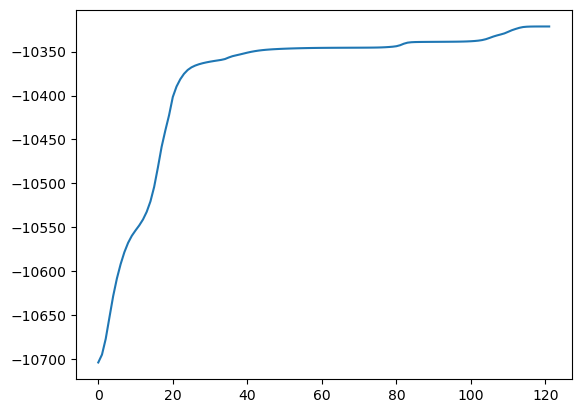

In [17]:
plt.plot(x, all_ll)
plt.show()

In [18]:
#Question 6b
#the probability of the first gene to belong to each of the three clusters
print(hm[0])

[3.78467096e-05 1.22716580e-01 8.77245574e-01]


In [19]:
#Question 6c

In [20]:
def RandomParams(gmm_data, k, n_features, epsilon=0.005, eye_covar = False):
    np.random.seed(2)
    means = gmm_data[np.random.choice(range(gmm_data.shape[0]),k,replace=False),:]
    if not eye_covar:
        covars = []
        for _ in range(k):
            covar = (np.eye(n_features,n_features)*np.random.sample())+np.random.normal(size=(n_features,n_features))
            covars += [covar.T.dot(covar)]
    else:
        covars = np.stack([np.diag(([1]*10))]*k)
    mix_props = np.random.sample(size=(k))
    mix_props = mix_props / np.sum(mix_props)
    return means, np.stack([x+np.eye(n_features,n_features)*epsilon for x in covars]), mix_props

In [21]:
thres = 0.001
final_ll = []
for num_clusters in range(3,11):
    print('num cluster: ',num_clusters)
    #random initializations
    random_means, random_covs, random_mixprops = RandomParams(new_data_t, num_clusters, 10)
    #print(random_covs)
    #call gmm_main
    all_ll, cluster_assignment, hm = gmm_main(new_data_t, random_means ,random_covs ,random_mixprops , thres)
    final_ll.append(all_ll[-1])

num cluster:  3
num cluster:  4
num cluster:  5
num cluster:  6
num cluster:  7
num cluster:  8
num cluster:  9
num cluster:  10


In [22]:
final_ll

[-10307.928501314485,
 -10223.207364852718,
 -10202.260642344978,
 -10117.900397651632,
 -9997.787912264524,
 -9947.645776117315,
 -9876.551052602925,
 -9806.229827389065]

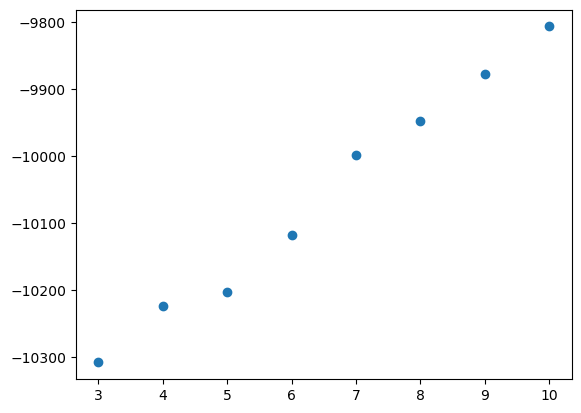

In [23]:
x2 = [(i+3) for i in range(len(final_ll))]
plt.scatter(x2, final_ll)
plt.show()